# Heart Disease Prediction: Feature Selection using Jellyfish Optimization Search (JS)
**Objective:** This project applies a custom Artificial Jellyfish Search (JFO) metaheuristic algorithm to optimize feature selection for medical diagnosis. 

To ensure complete scientific rigor and prevent feature selection bias (data leakage), the dataset undergoes a strict 80/20 stratified split. The JFO algorithm explores feature subsets using 5-Fold Cross-Validation exclusively on the training data. Final model performance is evaluated only once on the completely unseen test set.

In [1]:
import numpy as np
import pandas as pd
import random
import warnings

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## 1. Data Loading & Strict Partitioning
To prevent data leakage, the data is split into Training and Testing sets *before* any scaling occurs. The scaler is fitted only to the training data.

In [2]:
data = pd.read_csv("Heart_disease_cleveland_new.csv")
feature_names = list(data.drop("target", axis=1).columns)
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,0,110,264,0,0,132,0,1.2,1,0,3,1
299,68,1,3,144,193,1,0,141,0,3.4,1,2,3,1
300,57,1,3,130,131,0,0,115,1,1.2,1,1,3,1
301,57,0,1,130,236,0,2,174,0,0.0,1,1,1,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,2.158416,0.960126,0.0,2.0,2.0,3.0,3.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [5]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
X = data.drop("target", axis=1).to_numpy()
y = data["target"].to_numpy()

# 80/20 Split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Training Set : {X_trainval.shape[0]} samples")
print(f"Test Set     : {X_test.shape[0]} samples")

# Scaling
scaler = StandardScaler()
X_trainval = scaler.fit_transform(X_trainval)
X_test = scaler.transform(X_test)

Training Set : 242 samples
Test Set     : 61 samples


## 2. Evaluation Mechanics
Defining the standard evaluation function for the final test set, the cross-validation function for the JFO training phase, and the baseline classifiers.

In [8]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)

    pred = model.predict(X_te)
    prob = model.predict_proba(X_te)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()

    acc = accuracy_score(y_te, pred)
    sen = tp / (tp + fn)
    spe = tn / (tn + fp)
    auc = roc_auc_score(y_te, prob)

    return acc, sen, spe, auc, prob

def cross_val_score(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    acc_list, auc_list = [], []

    for tr, val in skf.split(X, y):
        m = type(model)(**model.get_params())
        m.fit(X[tr], y[tr])

        pred = m.predict(X[val])
        prob = m.predict_proba(X[val])[:, 1]

        acc_list.append(accuracy_score(y[val], pred))
        auc_list.append(roc_auc_score(y[val], prob))

    return np.mean(acc_list), np.mean(auc_list)

def get_models():
    return {
        "SVM": SVC(kernel='rbf', C=10, gamma='scale',
                   probability=True, random_state=SEED),
        "Decision Tree": DecisionTreeClassifier(random_state=SEED),
        "AdaBoost": AdaBoostClassifier(random_state=SEED),
        "ANN": MLPClassifier(max_iter=500, random_state=SEED)
    }

## 3. Artificial Jellyfish Search (JFO) Architecture
The metaheuristic optimization class. The fitness function balances 60% Accuracy and 40% AUC, applying a penalty to encourage dimensionality reduction.

In [9]:
class Jellyfish:
    def __init__(self, model, n_pop=10, max_iter=30, beta=3.0, gamma=0.1):
        self.model = model
        self.n_pop = n_pop
        self.max_iter = max_iter
        self.beta = beta
        self.gamma = gamma

    def fitness(self, sol):
        idx = np.where(sol > 0.4)[0]

        if len(idx) < 5 or len(idx) == X_trainval.shape[1]:
            return 0

        X_sub = X_trainval[:, idx]

        m = type(self.model)(**self.model.get_params())
        acc, auc = cross_val_score(m, X_sub, y_trainval)

        return (0.6 * acc + 0.4 * auc) - 0.001 * (len(idx) / X_trainval.shape[1])

    def optimize(self):
        dim = X_trainval.shape[1]

        pop = np.random.rand(self.n_pop, dim)
        scores = [self.fitness(pop[i]) for i in range(self.n_pop)]

        best = pop[np.argmax(scores)].copy()
        best_score = max(scores)

        for t in range(self.max_iter):
            mean = np.mean(pop, axis=0)

            for i in range(self.n_pop):
                ct = abs((1 - t / self.max_iter) * (2 * random.random() - 1))

                if ct >= 0.5:
                    trend = best - self.beta * random.random() * mean
                    pop[i] += random.random() * trend
                else:
                    if random.random() < 0.5:
                        pop[i] += self.gamma * random.random()
                    else:
                        j = random.randint(0, self.n_pop - 1)

                        if scores[i] < scores[j]:
                            pop[i] += random.random() * (pop[j] - pop[i])
                        else:
                            pop[i] += random.random() * (pop[i] - pop[j])

                pop[i] = np.clip(pop[i], 0, 1)

                sc = self.fitness(pop[i])
                scores[i] = sc

                if sc > best_score:
                    best_score = sc
                    best = pop[i].copy()

        return best

## 4. Establishing the Baseline
Evaluating all four models using the standard 13-feature set.

In [10]:
print("="*50)
print("  BASELINE MODELS (All Features)")
print("="*50)

baseline_results = {}
base_probs = {}

for name, model in get_models().items():
    acc, sen, spe, auc, prob = evaluate(model, X_trainval, y_trainval, X_test, y_test)
    
    baseline_results[name] = (acc, sen, spe, auc)
    base_probs[name] = prob
    
    print(name,':')
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC:      {auc:.4f}")
    print(f"Sensitivity: {sen:.4f}")
    print(f"Specificity: {spe:.4f}")
    print("-" * 53)

  BASELINE MODELS (All Features)
SVM :
Accuracy: 0.8033
AUC:      0.8994
Sensitivity: 0.9643
Specificity: 0.6667
-----------------------------------------------------
Decision Tree :
Accuracy: 0.7213
AUC:      0.7289
Sensitivity: 0.8214
Specificity: 0.6364
-----------------------------------------------------
AdaBoost :
Accuracy: 0.8852
AUC:      0.9675
Sensitivity: 0.9643
Specificity: 0.8182
-----------------------------------------------------
ANN :
Accuracy: 0.8361
AUC:      0.9351
Sensitivity: 0.9643
Specificity: 0.7273
-----------------------------------------------------


## 5. Applying Jellyfish Optimization
Executing the JFO algorithm to locate the optimal feature subset for each model, then evaluating that specific subset on the unseen test data.

In [11]:
print("\n=====================================================")
print("  JFO OPTIMIZED MODELS")
print("=====================================================")

jfo_probs = {}

for name, model in get_models().items():
    print(f"\nRunning JFO for {name}...")

    jf = Jellyfish(model)
    best_sol = jf.optimize()

    idx = np.where(best_sol > 0.4)[0]
    
    selected_features = [feature_names[i] for i in idx]
    
    acc, sen, spe, auc, prob = evaluate(
        model,
        X_trainval[:, idx], y_trainval,
        X_test[:, idx], y_test
    )

    jfo_probs[name] = prob

    b_acc = baseline_results[name][0]
    b_sen = baseline_results[name][1]
    b_spe = baseline_results[name][2]
    b_auc = baseline_results[name][3]
    
    print(f"Features Selected [{len(idx)}/13]: {selected_features}")
    print(f"Accuracy: {acc:.4f} (difference {acc - b_acc:+.4f})")
    print(f"AUC:      {auc:.4f} (difference {auc - b_auc:+.4f})")
    print(f"Sensitivity: {sen:.4f} (difference {sen - b_sen:+.4f})")
    print(f"Specificity: {spe:.4f} (difference {spe - b_spe:+.4f})")
    print("-" * 53)


  JFO OPTIMIZED MODELS

Running JFO for SVM...
Features Selected [8/13]: ['age', 'sex', 'cp', 'thalach', 'exang', 'oldpeak', 'ca', 'thal']
Accuracy: 0.8689 (difference +0.0656)
AUC:      0.9524 (difference +0.0530)
Sensitivity: 0.9286 (difference -0.0357)
Specificity: 0.8182 (difference +0.1515)
-----------------------------------------------------

Running JFO for Decision Tree...
Features Selected [10/13]: ['age', 'sex', 'cp', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Accuracy: 0.8197 (difference +0.0984)
AUC:      0.8279 (difference +0.0990)
Sensitivity: 0.9286 (difference +0.1071)
Specificity: 0.7273 (difference +0.0909)
-----------------------------------------------------

Running JFO for AdaBoost...
Features Selected [9/13]: ['age', 'sex', 'cp', 'trestbps', 'thalach', 'exang', 'slope', 'ca', 'thal']
Accuracy: 0.8852 (difference +0.0000)
AUC:      0.9535 (difference -0.0141)
Sensitivity: 0.9286 (difference -0.0357)
Specificity: 0.8485 (difference +0.0303)
----

## 6. ROC Curve Analysis
Visualizing the trade-off between the True Positive Rate (Sensitivity) and False Positive Rate (1 - Specificity) for both the Baseline and JFO-Optimized models.

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

def plot_roc(model_name):
    fig, ax = plt.subplots()

    RocCurveDisplay.from_predictions(
        y_test, base_probs[model_name], name="Baseline", ax=ax
    )
    RocCurveDisplay.from_predictions(
        y_test, jfo_probs[model_name], name="JFO", ax=ax
    )

    plt.title(f"ROC Curve: {model_name}")
    plt.show()

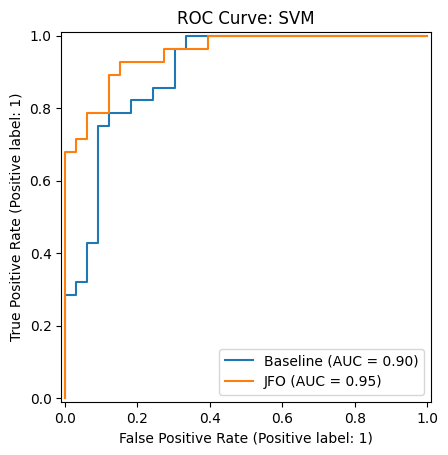

In [13]:
plot_roc("SVM")

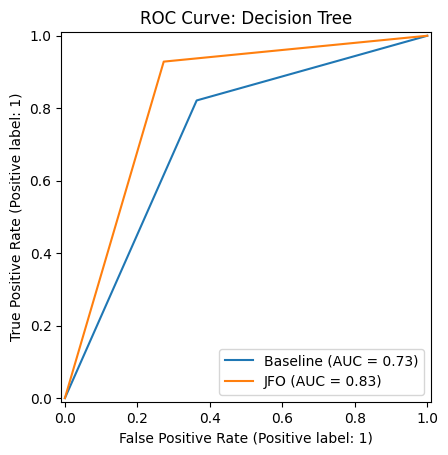

In [14]:
plot_roc("Decision Tree")

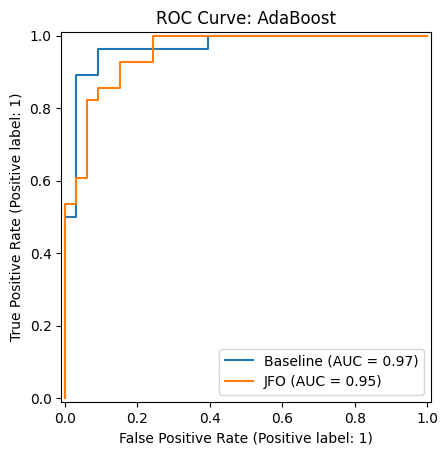

In [15]:
plot_roc("AdaBoost")

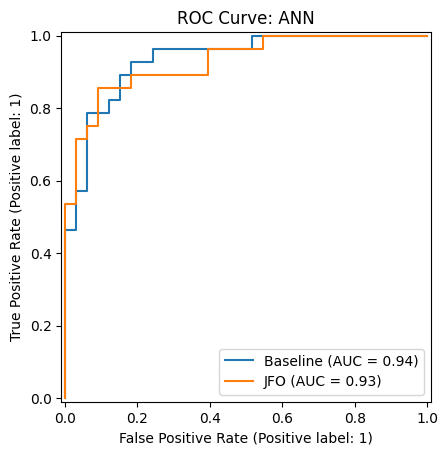

In [16]:
plot_roc("ANN")